In [7]:
import numpy as np
import pandas as pd

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [10]:
# this reads the clustered and HOF annotated data
AUdf = pd.read_csv("../copyfiles/AU_cluster5_PUB", sep="\t") 
print(AUdf.shape)
AUdf.head()

(712261, 65)


,Id,Study,Session,SL,TL,Task,Text,Part,Time,Phase,Type,Dur,SGid,SGnbr,TGid,TGnbr,Ins,Del,PosS,PosT,Scatter,CrossS,CrossT,Gram5,GazePath,FixS,TrtS,FixT,TrtT,KBI,PUB,Edit,ProbSgaze,ProbTgaze,ProbCgaze,ProbSTCgaze,HSgaze,HTgaze,HCgaze,HSTCgaze,StudySession,End,Dur_L,Dur_R,Dur_S,Dur_N,STs_TTs,NextTime,Total_Dur,One,MaxDur,RelDur_L,RelDur_R,RelDur_S,RelDur_N,GPlabel,KBtype,PUnbr,PUdur,KBnbr,KBdur,HOF,WperFix,HOFnbr,Tstyles
0,1,AR22,P05_T4,en,ar,T,4,P05,46,O,1,735,---,0,---,0,0,0,---,---,0.0,0.0,0.0,10000,S:3+S:37+S:25+T:1,3,700,1,0,500,2061,---,0.9773,0.3409,0.3182,0.1364,0.1099,2.6418,1.7598,3.1548,AR22-P05_T4,781,0,0,713,22,3,781.0,735,1,735,0.000000,0.00000,0.970068,0.029932,S,P,1,76829,1,76829,O,0.600000,1,1
1,2,AR22,P05_T4,en,ar,T,4,P05,781,O,2,171,---,0,---,0,0,0,---,---,0.0,0.0,0.0,21000,T:1+S:8,1,0,1,171,500,2061,---,0.8636,0.0455,0.3636,0.0455,0.6217,3.6441,1.9569,3.6441,AR22-P05_T4,952,0,0,171,0,1,952.0,171,1,171,0.000000,0.00000,1.000000,0.000000,S,P,1,76829,1,76829,O,0.333333,1,1
2,3,AR22,P05_T4,en,ar,T,4,P05,952,O,1,49938,---,0,---,0,0,0,---,---,0.0,0.0,0.0,12100,T:1+S:8+S:1+S:1+S:2+S:2+S:1+S:1+S:1+S:1+S:1+S:...,104,48824,2,5,500,2061,---,0.6908,0.1582,0.3885,0.1051,0.8596,3.0752,1.8944,3.3639,AR22-P05_T4,50890,716,416,48443,363,68,50890.0,49938,1,49938,0.014338,0.00833,0.970063,0.007269,S,P,1,76829,1,76829,O,0.635514,1,1
3,4,AR22,P05_T4,en,ar,T,4,P05,50890,O,2,547,---,0,---,0,0,0,---,---,0.0,0.0,0.0,21210,T:1+S:1,1,0,1,518,500,2061,---,1.0000,0.0455,0.2727,0.0455,0.0000,3.4085,1.7990,3.4085,AR22-P05_T4,51437,0,0,518,29,1,51437.0,547,1,547,0.000000,0.00000,0.946984,0.053016,S,P,1,76829,1,76829,O,0.333333,1,1
4,5,AR22,P05_T4,en,ar,T,4,P05,51437,O,1,23988,---,0,---,0,0,0,---,---,0.0,0.0,0.0,12121,S:1+S:2+S:1+S:1+S:1+S:1+S:8+S:10+S:8+S:2+S:4+S...,57,23424,0,0,500,2061,---,0.7568,0.1579,0.3501,0.0877,0.5721,3.0636,1.8613,3.3328,AR22-P05_T4,75425,4754,0,19234,0,21,75425.0,23988,1,23988,0.198182,0.00000,0.801818,0.000000,S,P,1,76829,1,76829,O,0.362069,1,1


In [5]:
AUdf["StudySession"].value_counts()

StudySession
RH12-P02_A2              2936
BB17-P13_T1              2255
ZHPT12-P2_T2             2233
MAecho2019-P06_T02       2163
ZHPT12-P3_T2             2072
ZHPT12-P15_T2            2072
RH12-P01_A1              2058
MAecho2019-P26_T02       2031
CET6-P14_T02             1971
ST19-P23_T2              1801
BB17-P14_T1              1799
MAecho2019-P21_T02       1759
CET6-P14_T03             1753
ZHPT12-P7_T2             1742
MAecho2019-P01_T02       1704
ST19-P55_T3              1688
SG12-P09_T5              1658
NJ12-P11_T6              1639
predict20-P02_T48        1630
ST19-P24_T1              1623
ZHPT12-P4_T2             1621
CET6-P06_T03             1611
MAecho2019-P26_T01       1605
CET6-P14_T01             1597
MAecho2019-P05_T02       1565
NJ12-P11_T4              1527
MAecho2019-P01_T01       1524
SG12-P13_T3              1518
JLG10-P07_T6             1514
ZHPT12-P8_T2             1512
AR22-P16_T1              1506
BACK2020-P12_T1          1504
SG12-P07_T3              15

- sequences of AUs of type 1 (ST reading), 2 (TT reading), or 8 (no observed behavior) are the ones that cluster into pauses (KBIs or PUBs).

In [6]:
# Filter for pause-like AUs (Types 1, 2, 5, 6) 
study = AUdf[AUdf["StudySession"] == "NJ12-P11_T6"]
pause_aus = study[study['Type'].isin([1, 2, 5, 6])].copy()

In [6]:
pause_aus.shape

(1130, 65)

In [7]:
# Define a function to classify each AU as a KBI or PUB
def classify_pause(row):
    # A PUB is an intentional break with a duration > the PUB threshold 
    if row['Dur'] > row['PUB']:
        return 'PUB'
    # A KBI is a non-intentional halt with a duration > KBI threshold 
    elif row['Dur'] > row['KBI']:
        return 'KBI'
    else:
        return 'Short Pause'

In [8]:
# Apply the function to create the 'PauseType' column
pause_aus['PauseType'] = pause_aus.apply(classify_pause, axis=1)

# Filter out short pauses that are below the KBI threshold
final_pauses = pause_aus[pause_aus['PauseType'].isin(['KBI', 'PUB', 'Short Pause'])].copy()

print("Data successfully filtered and classified. Resulting pause data:")
final_pauses.head()


Data successfully filtered and classified. Resulting pause data:


,Id,Study,Session,SL,TL,Task,Text,Part,Time,Phase,Type,Dur,SGid,SGnbr,TGid,TGnbr,Ins,Del,PosS,PosT,Scatter,CrossS,CrossT,Gram5,GazePath,FixS,TrtS,FixT,TrtT,KBI,PUB,Edit,ProbSgaze,ProbTgaze,ProbCgaze,ProbSTCgaze,HSgaze,HTgaze,HCgaze,HSTCgaze,StudySession,End,Dur_L,Dur_R,Dur_S,Dur_N,STs_TTs,NextTime,Total_Dur,One,MaxDur,RelDur_L,RelDur_R,RelDur_S,RelDur_N,GPlabel,KBtype,PUnbr,PUdur,KBnbr,KBdur,HOF,WperFix,HOFnbr,Tstyles,PauseType
305944,1,NJ12,P11_T6,en,hi,T,6,P11,1263,O,1,3697,---,0,---,0,0,0,---,---,0.0,0.0,0.0,10000,S:6+S:6+S:8+S:8+S:7+S:7+S:7+S:49+S:87+S:111+S:...,34,2747,1,0,592,2808,---,0.5580,0.1412,0.2067,0.0807,0.8627,2.9425,2.2656,3.5509,NJ12-P11_T6,4960,1567,1355,749,26,17,4960.0,3697,1,3697,0.423857,0.366513,0.202597,0.007033,LR,P,1,55615,1,55615,O,0.472222,1,1,PUB
305945,2,NJ12,P11_T6,en,hi,T,6,P11,4960,O,2,1080,---,0,---,0,0,0,---,---,0.0,0.0,0.0,21000,T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:1,0,0,10,600,592,2808,---,0.5294,0.0588,0.0588,0.0588,1.2533,3.5725,2.5869,3.9698,NJ12-P11_T6,6040,0,890,190,0,1,6040.0,1080,1,1080,0.000000,0.824074,0.175926,0.000000,R,P,1,55615,1,55615,O,0.090909,1,1,KBI
305947,4,NJ12,P11_T6,en,hi,T,6,P11,37533,O,1,3033,---,0,---,0,0,0,---,---,0.0,0.0,0.0,18210,S:19+S:137+S:137+S:137+S:135+S:107+S:85+S:38+S...,25,2531,0,0,592,2808,---,0.3271,0.0800,0.2235,0.0753,1.2733,3.2230,2.1396,3.5462,NJ12-P11_T6,40566,526,1887,620,0,12,40566.0,3033,1,3033,0.173426,0.622156,0.204418,0.000000,R,P,1,55615,1,55615,O,0.461538,1,1,PUB
305949,6,NJ12,P11_T6,en,hi,T,6,P11,48937,O,1,1041,---,0,---,0,0,0,---,---,0.0,0.0,0.0,18182,S:3+S:20+S:20+S:13+S:2+S:2+S:2+S:1,8,935,0,0,592,2808,---,0.2868,0.0588,0.1103,0.0588,1.3015,2.9526,1.6693,3.4440,NJ12-P11_T6,49978,0,234,807,0,5,49978.0,1041,1,1041,0.000000,0.224784,0.775216,0.000000,S,P,1,55615,1,55615,H,0.555556,2,1,KBI
305954,11,NJ12,P11_T6,en,hi,T,6,P11,58143,D,2,10773,---,0,---,0,0,0,---,---,0.0,0.0,0.0,24848,T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:1+T:...,0,0,53,9390,592,2808,---,0.5294,0.0588,0.0588,0.0588,1.2533,3.5725,2.5869,3.9698,NJ12-P11_T6,68916,0,10176,597,0,1,68916.0,10773,1,10773,0.000000,0.944584,0.055416,0.000000,R,P,3,12089,5,12089,H,0.018519,2,1,PUB


In [9]:
pause_aus['PauseType'].value_counts()

PauseType
Short Pause    752
KBI            316
PUB             62
Name: count, dtype: int64

In [10]:
print("--- Method 1: Descriptive Statistics & Visualization ---")

# Calculate descriptive statistics for gaze features, grouped by PauseType
gaze_stats = final_pauses.groupby('PauseType')[['Dur_L', 'Dur_R', 'Dur_S']].describe()
print("Summary statistics for gaze durations by pause type:")
gaze_stats

--- Method 1: Descriptive Statistics & Visualization ---
Summary statistics for gaze durations by pause type:


Dur_L                                                         \
             count         mean          std  min    25%     50%      75%   
PauseType                                                                   
KBI          316.0   242.208861   433.783562  0.0    0.0     0.0   390.75   
PUB           62.0  1885.241935  1459.516490  0.0  640.5  1798.5  2759.25   
Short Pause  752.0    36.916223    96.335326  0.0    0.0     0.0     0.00   

                     Dur_R                                                  \
                max  count         mean          std  min      25%     50%   
PauseType                                                                    
KBI          2556.0  316.0   527.389241   488.236084  0.0   139.25   443.0   
PUB          5605.0   62.0  2008.967742  1653.829654  0.0  1042.00  1627.0   
Short Pause   547.0  752.0    99.074468   142.825044  0.0     0.00     1.0   

                               Dur_S                                       \
                 75%      max  count         mean         std  min    25%   
PauseType                                                                   
KBI           802.25   2479.0  316.0   277.762658  378.861575  0.0    0.0   
PUB          2787.50  10176.0   62.0  1020.580645  941.144569  0.0  307.5   
Short Pause   178.00    574.0  752.0    53.134309   96.136079  0.0    0.0   

                                     
               50%      75%     max  
PauseType                            
KBI           81.0   465.50  2192.0  
PUB          728.5  1302.75  3987.0  
Short Pause    0.0    67.00   566.0

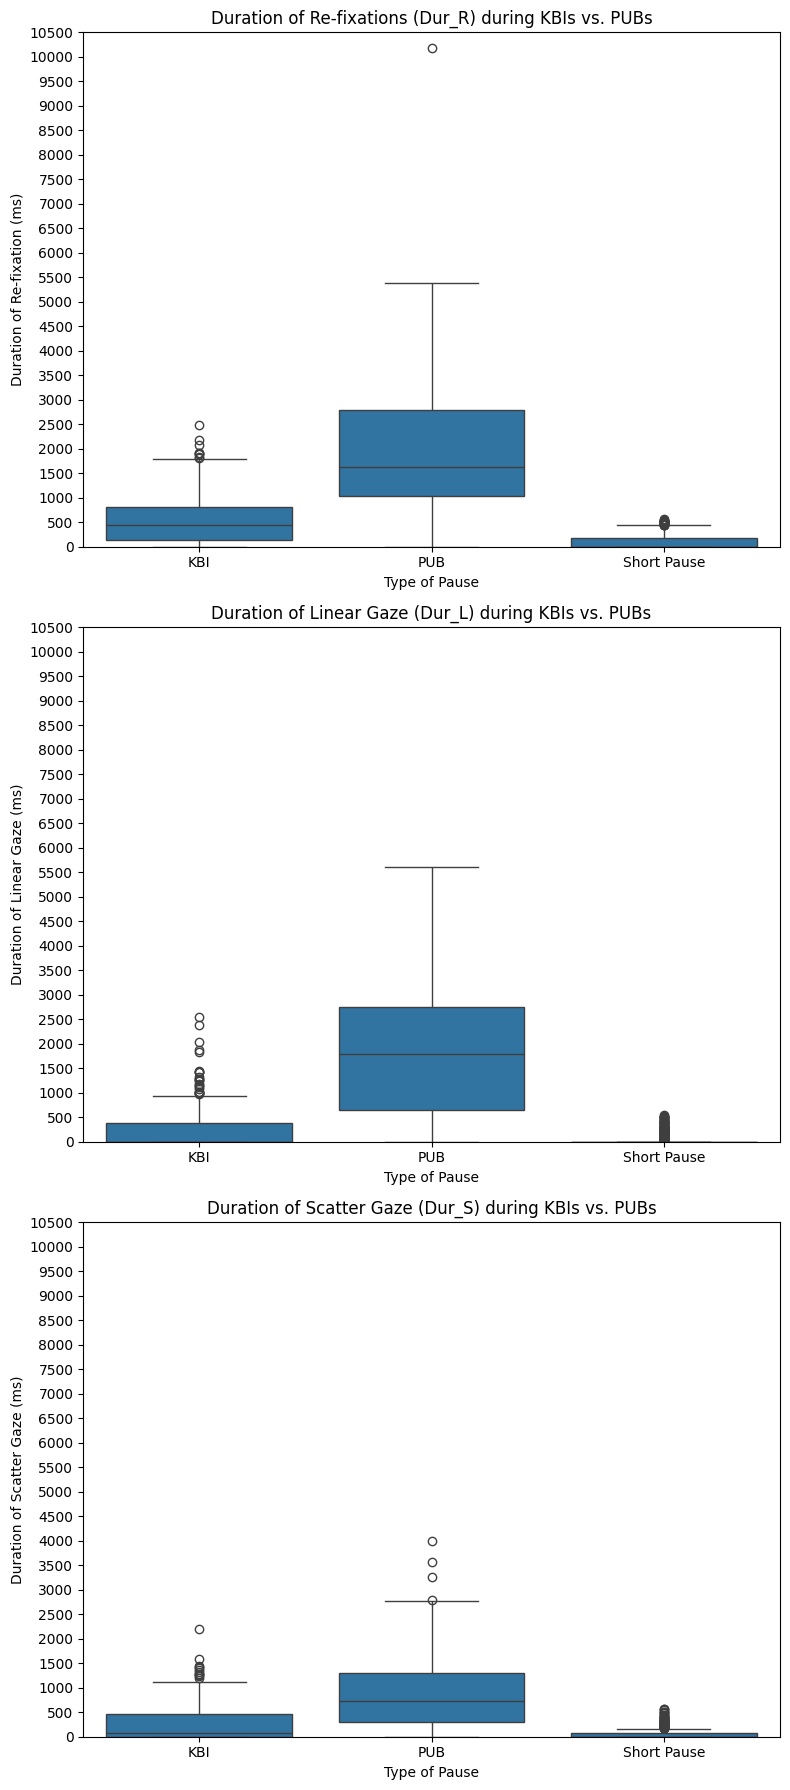

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns
import math

# plot box plots to visualize the differences in gaze durations across pause types

fig, axes = plt.subplots(3, 1, figsize=(8, 18))
# Visualize the difference in Re-fixation Duration (Dur_R)
sns.boxplot(x='PauseType', y='Dur_R', data=final_pauses,
            order=['KBI', 'PUB', 'Short Pause'], ax=axes[0])
axes[0].set_title('Duration of Re-fixations (Dur_R) during KBIs vs. PUBs')
axes[0].set_xlabel('Type of Pause')
axes[0].set_ylabel('Duration of Re-fixation (ms)')          

# Visualize the difference in Linear Gaze Duration (Dur_L)
sns.boxplot(x='PauseType', y='Dur_L', data=final_pauses,
            order=['KBI', 'PUB', 'Short Pause'], ax=axes[1])
axes[1].set_title('Duration of Linear Gaze (Dur_L) during KBIs vs. PUBs')
axes[1].set_xlabel('Type of Pause')
axes[1].set_ylabel('Duration of Linear Gaze (ms)')

# Visualize the difference in Scatter Gaze Duration (Dur_S)
sns.boxplot(x='PauseType', y='Dur_S', data=final_pauses,
            order=['KBI', 'PUB', 'Short Pause'], ax=axes[2])
axes[2].set_title('Duration of Scatter Gaze (Dur_S) during KBIs vs. PUBs')
axes[2].set_xlabel('Type of Pause')
axes[2].set_ylabel('Duration of Scatter Gaze (ms)')  

# Find the maximum value among all three columns
max_val = max(
    final_pauses['Dur_R'].max(),
    final_pauses['Dur_L'].max(),
    final_pauses['Dur_S'].max()
)

# Round up to the next 500 for a clean axis
ymax = int(math.ceil(max_val / 500.0)) * 500

# Set the same y-axis for all plots
for ax in axes:
    ax.set_ylim(0, ymax)
    ax.set_yticks(np.arange(0, ymax + 1, 500))

plt.tight_layout()
plt.show()

In [15]:
# --- Method 2: Correlation Analysis ---
print("--- Method 2: Correlation Analysis ---")

# Separate the data into two groups
kbi_pauses = final_pauses[final_pauses['PauseType'] == 'KBI']
pub_pauses = final_pauses[final_pauses['PauseType'] == 'PUB']
short_pauses = final_pauses[final_pauses['PauseType'] == 'Short Pause']

# Check if there are enough data points in each group
if not pub_pauses.empty:
    # Calculate correlation for PUBs
    pub_correlation = pub_pauses[['Dur','Dur_S', 'Dur_L', 'Dur_R']].corr()
    print("Correlation Matrix for PUBs:")
    print(pub_correlation)
else:
    print("No PUBs found in the data to analyze.")

if not kbi_pauses.empty:
    # Calculate correlation for KBIs
    kbi_correlation = kbi_pauses[['Dur','Dur_S', 'Dur_L', 'Dur_R']].corr()
    print("\nCorrelation Matrix for KBIs:")
    print(kbi_correlation)
else:
    print("No KBIs found in the data to analyze.")

if not short_pauses.empty:
    # Calculate correlation for Short Pauses
    short_correlation = short_pauses[['Dur','Dur_S', 'Dur_L', 'Dur_R']].corr()
    print("\nCorrelation Matrix for Short Pauses:")
    print(short_correlation)
else:
    print("No Short Pauses found in the data to analyze.")


--- Method 2: Correlation Analysis ---
Correlation Matrix for PUBs:
            Dur     Dur_S     Dur_L     Dur_R
Dur    1.000000  0.618100  0.578487  0.533766
Dur_S  0.618100  1.000000  0.350413 -0.009915
Dur_L  0.578487  0.350413  1.000000 -0.278245
Dur_R  0.533766 -0.009915 -0.278245  1.000000

Correlation Matrix for KBIs:
            Dur     Dur_S     Dur_L     Dur_R
Dur    1.000000  0.254986  0.431401  0.486416
Dur_S  0.254986  1.000000 -0.195874 -0.251832
Dur_L  0.431401 -0.195874  1.000000 -0.259171
Dur_R  0.486416 -0.251832 -0.259171  1.000000

Correlation Matrix for Short Pauses:
            Dur     Dur_S     Dur_L     Dur_R
Dur    1.000000  0.379497  0.280242  0.637822
Dur_S  0.379497  1.000000 -0.168942 -0.139628
Dur_L  0.280242 -0.168942  1.000000 -0.227409
Dur_R  0.637822 -0.139628 -0.227409  1.000000


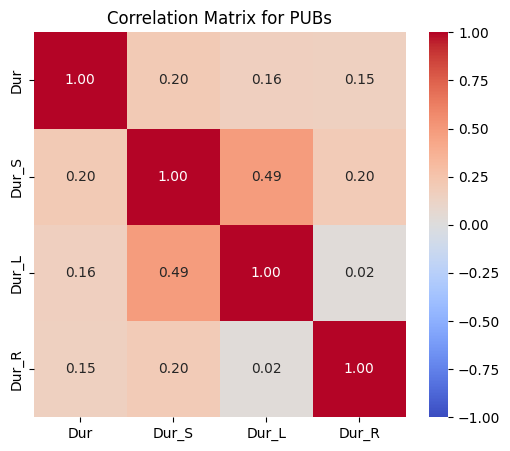

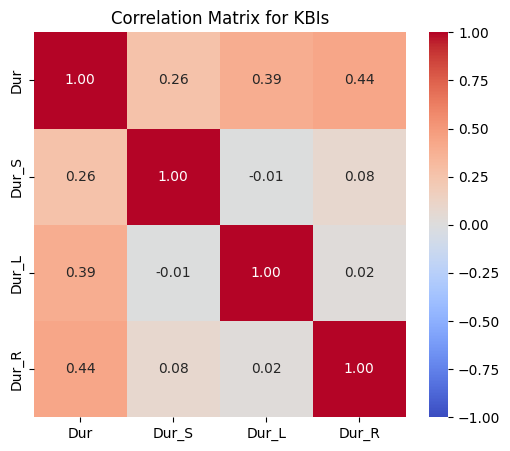

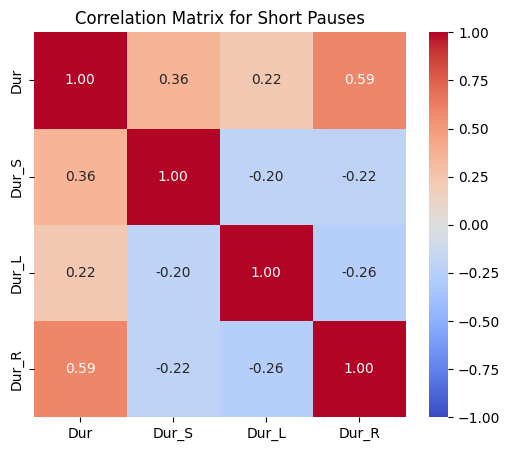

In [82]:
# visualize the correlation matrices
def plot_correlation_matrix(corr_matrix, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(title)
    plt.show()

plot_correlation_matrix(pub_correlation, "Correlation Matrix for PUBs")
plot_correlation_matrix(kbi_correlation, "Correlation Matrix for KBIs")
plot_correlation_matrix(short_correlation, "Correlation Matrix for Short Pauses")

In [19]:
import scipy.stats as stats
# --- Method 3: Group Comparison with Statistical Tests ---
print("--- Method 3: Group Comparison with Statistical Tests ---")

# Check if both groups have data for the test
if not kbi_pauses.empty and not pub_pauses.empty and not short_pauses.empty:

    print("=="*20)

    dur_r_kbi_relative = final_pauses[final_pauses['PauseType'] == 'KBI']['RelDur_R']
    dur_r_pub_relative = final_pauses[final_pauses['PauseType'] == 'PUB']['RelDur_R']
    dur_r_sp_relative = final_pauses[final_pauses['PauseType'] == 'Short Pause']['RelDur_R']
    dur_l_kbi_relative = final_pauses[final_pauses['PauseType'] == 'KBI']['RelDur_L']
    dur_l_pub_relative = final_pauses[final_pauses['PauseType'] == 'PUB']['RelDur_L']
    dur_l_sp_relative = final_pauses[final_pauses['PauseType'] == 'Short Pause']['RelDur_L']
    dur_s_kbi_relative = final_pauses[final_pauses['PauseType'] == 'KBI']['RelDur_S']
    dur_s_pub_relative = final_pauses[final_pauses['PauseType'] == 'PUB']['RelDur_S']
    dur_s_sp_relative = final_pauses[final_pauses['PauseType'] == 'Short Pause']['RelDur_S']

    # Perform an independent t-test on the relative durations
    t_stat_rel, p_value_rel = stats.ttest_ind(dur_r_pub_relative, dur_r_kbi_relative, equal_var=False, nan_policy='omit')
    t_stat_lin, p_value_lin = stats.ttest_ind(dur_l_pub_relative, dur_l_kbi_relative, equal_var=False, nan_policy='omit')
    t_stat_sca, p_value_sca = stats.ttest_ind(dur_s_pub_relative, dur_s_kbi_relative, equal_var=False, nan_policy='omit')
    t_stat_sca_sp, p_value_sca_sp = stats.ttest_ind(dur_s_pub_relative, dur_s_sp_relative, equal_var=False, nan_policy='omit')


    print(f"\nT-test for comparing RELATIVE Dur_R between PUBs")
    print(f"T-statistic: {t_stat_rel:.4f}")
    print(f"P-value: {p_value_rel:.4f}")
    print(f"\nT-test for comparing RELATIVE Dur_L between PUBs")
    print(f"T-statistic: {t_stat_lin:.4f}")
    print(f"P-value: {p_value_lin:.4f}")
    print(f"\nT-test for comparing RELATIVE Dur_S between PUBs")
    print(f"T-statistic: {t_stat_sca:.4f}")
    print(f"P-value: {p_value_sca:.4f}")
    print(f"\nT-test for comparing RELATIVE Dur_S between PUBs and Short Pauses")
    print(f"T-statistic: {t_stat_sca_sp:.4f}")
    print(f"P-value: {p_value_sca_sp:.4f}")

    if p_value_rel < 0.05:
        print("\nResult is statistically significant.")
        print("This suggests PUBs have a significantly different PROPORTION of time dedicated to re-fixation compared to KBIs.")
    else:
        print("\nResult is not statistically significant for re-fixation.")

    if p_value_lin < 0.05:
        print("\nResult is statistically significant.")
        print("This suggests PUBs have a significantly different PROPORTION of time dedicated to linear gaze compared to KBIs.")
    else:
        print("\nResult is not statistically significant for linear gaze.")
    
    if p_value_sca < 0.05:
        print("\nResult is statistically significant.")
        print("This suggests PUBs have a significantly different PROPORTION of time dedicated to scatter gaze compared to KBIs.")
    else:
        print("\nResult is not statistically significant for scatter gaze.")

    if p_value_sca_sp < 0.05:
        print("\nResult is statistically significant.")
        print("This suggests PUBs have a significantly different PROPORTION of time dedicated to scatter gaze compared to Short Pauses.")
    else:
        print("\nResult is not statistically significant for scatter gaze between PUBs and Short Pauses.")

else:
    print("Cannot perform t-test because one or both pause groups (KBI, PUB) are empty.")


--- Method 3: Group Comparison with Statistical Tests ---

T-test for comparing RELATIVE Dur_R between PUBs
T-statistic: -1.2562
P-value: 0.2117

T-test for comparing RELATIVE Dur_L between PUBs
T-statistic: 5.1245
P-value: 0.0000

T-test for comparing RELATIVE Dur_S between PUBs
T-statistic: -1.5625
P-value: 0.1200

T-test for comparing RELATIVE Dur_S between PUBs and Short Pauses
T-statistic: -3.1245
P-value: 0.0022

Result is not statistically significant for re-fixation.

Result is statistically significant.
This suggests PUBs have a significantly different PROPORTION of time dedicated to linear gaze compared to KBIs.

Result is not statistically significant for scatter gaze.

Result is statistically significant.
This suggests PUBs have a significantly different PROPORTION of time dedicated to scatter gaze compared to Short Pauses.
